In [1]:
#Step1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
#Step2 - load dataset
data = pd.read_csv("train.csv")
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [3]:
#Step3 - Check Missing Values
data.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [4]:
# Observations:
# PoolQC, MiscFeature, Alley, Fence have very high missing values

In [5]:
#Step4 -  Handle Missing Values
cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

for col in cols_none:
    data[col] = data[col].fillna("None")
data["MasVnrType"] = data["MasVnrType"].fillna("None")

# Garage year
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)

# Numerical columns
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())
data["MasVnrArea"] = data["MasVnrArea"].fillna(data["MasVnrArea"].median())

# Electrical (mode)
data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

In [6]:
data.isnull().sum().sum()

np.int64(0)

In [7]:
#Step5 - Drop Irrelevant Columns
data.drop("Id",axis=1,inplace=True)

In [8]:
#Step6 - Convert Categorical Features to Numerical(Encoding)
data = pd.get_dummies(data,drop_first=True)

In [9]:
data.shape

(1460, 260)

In [10]:
#Step7 - Split Features(X) and Target(y)
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

In [11]:
#Step8 - Train-Test-Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#Step9 - Train Random Forest Model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
#Step10 - Make Predictions
y_pred = model.predict(X_test)

In [14]:
#Step11 - Evaluate Model
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 29179.08917390406


In [15]:
#Check Average House Price
data["SalePrice"].mean()

np.float64(180921.19589041095)

<Axes: >

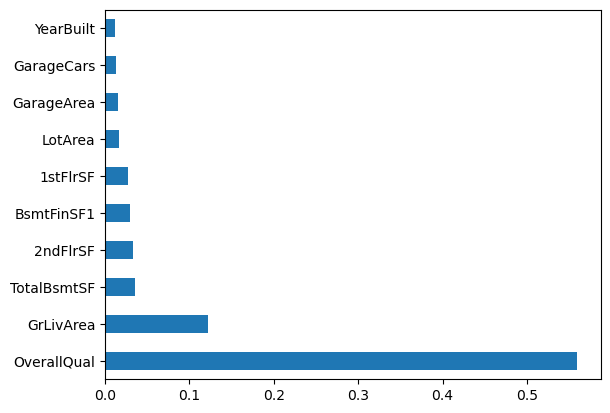

In [18]:
#Step12 - Feature Improvement
import pandas as pd
feature_improvements = pd.Series(model.feature_importances_,index=X.columns)
feature_improvements.nlargest(10).plot(kind='barh')

In [19]:
#Step13 - Improve Model
model = RandomForestRegressor(n_estimators=200,max_depth=20,random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
#Step14 - Make Predictions
y_pred = model.predict(X_test)

In [21]:
#Step15 - Evaluate Model(Root-Mean-Squared Error)
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 28775.526711105522


In [22]:
#Step16 - Save Model
import pickle
pickle.dump(model, open("house_model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [23]:
#Step17 - Test Loading
model = pickle.load(open("house_model.pkl", "rb"))
cols = pickle.load(open("columns.pkl", "rb"))

In [24]:
#Step18 - Test Prediction
sample = X_test.iloc[0].values.reshape(1, -1)
print(model.predict(sample))

[140719.23863636]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
